##### `Stape 1 : Prepare The Data`

In [1]:
"""IMPORT EVERYTHING.. """
# Data manipulation
import pandas as pd
import numpy as np

# # Quantitative analysis / indicators
# import talib
# import backtrader as bt

# # Machine learning / statistics
# import scipy
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# # Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf


from resampler import OHLCVResampler
# # Jupyter Notebook magic for inline plots
# %matplotlib inline


In [2]:
"""Load Source OHLCV dta"""

df = pd.read_parquet("../Src/XAUUSDc_M1.parquet", engine="pyarrow")

In [3]:
"""Setting Chart Configs"""
from ChartterX5 import Chartter

chartter = Chartter(config={
    'chart_type': 'candle',
    'style': 'charles',
    'volume': False
})

chartter._setup_tradingview_theme()

cnf = {
        'title': 'NONE',
        'style': chartter.tradingview_style,
        'volume': False,
        'show_nontrading': False,
        'datetime_format': '%Y-%m-%d',
        'xlabel': '',
        'ylabel': '',
        'xrotation': 0
    }
# result.head(3)

#### `lorem`

In [4]:
"""ReSample data for Better Visualisation and minimize Calculaion"""
resampler = OHLCVResampler(default_agg='last')

result = resampler.resample(df, '15min')

# result

In [5]:

# High–Low and Open–Close difference × 100000
result['HL'] = (result['high'] - result['low']) * 10

result['OC'] = ((result['open'] - result['close']) * 10).abs()


result['day'] = result.index.day_name()


result['hour'] = result.index.hour

result['HL_above_400'] = result['OC'] > 30



# Filter only March data (month = 3)
df_march = result[result.index.month == 4]


resultRaw = result.copy()

# result.index = result.index.tz_localize('UTC').tz_convert('Asia/Kolkata')

print('df_march')

print(result.head())

df_march
                         open      high       low     close  volume     HL  \
datetime                                                                     
2024-01-02 04:30:00  2064.593  2066.092  2063.301  2065.142      10  27.91   
2024-01-02 04:45:00  2065.159  2065.900  2064.443  2064.698      15  14.57   
2024-01-02 05:00:00  2064.664  2065.131  2063.634  2064.258      15  14.97   
2024-01-02 05:15:00  2064.259  2064.259  2062.643  2063.543      14  16.16   
2024-01-02 05:30:00  2063.347  2064.932  2063.331  2064.006      15  16.01   

                       OC      day  hour  HL_above_400  
datetime                                                
2024-01-02 04:30:00  5.49  Tuesday     4         False  
2024-01-02 04:45:00  4.61  Tuesday     4         False  
2024-01-02 05:00:00  4.06  Tuesday     5         False  
2024-01-02 05:15:00  7.16  Tuesday     5         False  
2024-01-02 05:30:00  6.59  Tuesday     5         False  


In [6]:

dfShape  = pd.Series(pd.unique(result.index.date), name='date').shape

match = (result['HL_above_400'] == True).sum()

# print (dfShape)

# print (match)

(35036, 10)


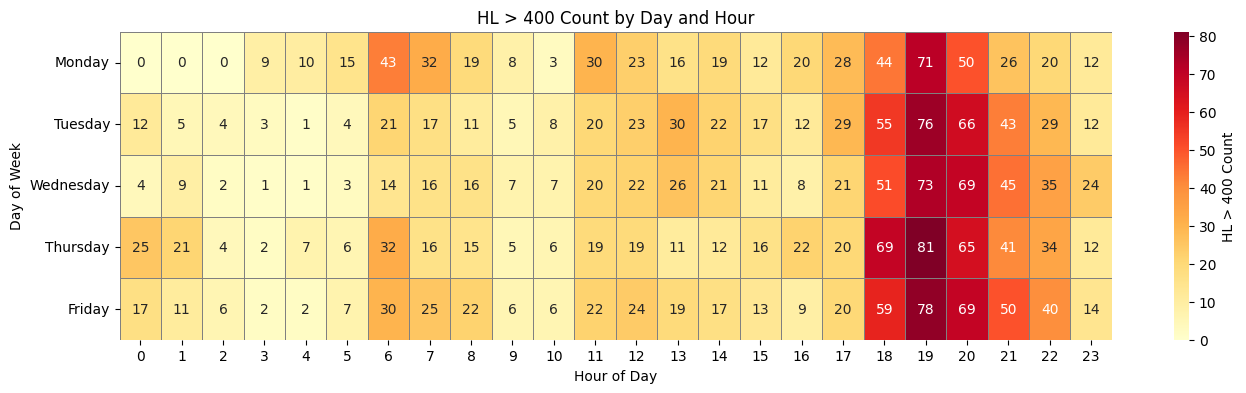

In [7]:
print(result.shape)

heatmap_data = result.pivot_table(
    index='day',
    columns='hour',
    values='HL_above_400',
    aggfunc='sum'
)

# Order days properly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
heatmap_data = heatmap_data.reindex(days_order)

# -------------------------------
# 6. Plot heatmap
# -------------------------------
plt.figure(figsize=(16,4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'HL > 400 Count'}
)
plt.title("HL > 400 Count by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

In [8]:
dta = resampler.resample(resultRaw,'15min', '2024-09-30', '2024-10-05')

mask = dta.index[dta['HL_above_400'] == True]

len(mask)


60

(481, 12)


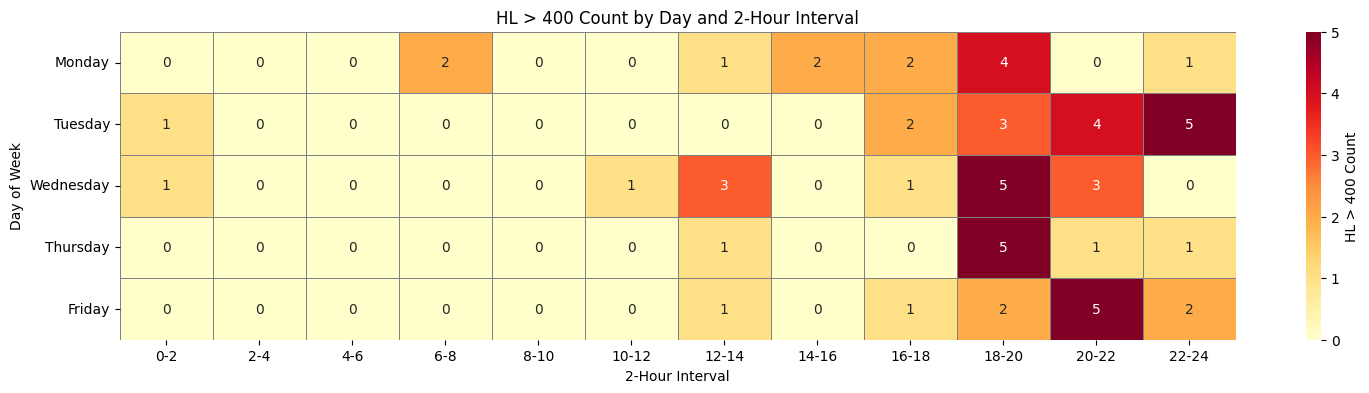

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# Create 2-hour time bins
# -------------------------------
# Assuming dta['hour'] is integer 0–23
dta['hour_group'] = (dta['hour'] // 2) * 2
dta['hour_label'] = dta['hour_group'].astype(str) + '-' + (dta['hour_group'] + 2).astype(str)

print(dta.shape)

# -------------------------------
# Create pivot table for heatmap
# -------------------------------
heatmap_data = dta.pivot_table(
    index='day',
    columns='hour_label',
    values='HL_above_400',
    aggfunc='sum'
)

# Order days properly
days_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
heatmap_data = heatmap_data.reindex(days_order)

# Ensure columns are in chronological order
expected_cols = [f"{i}-{i+2}" for i in range(0, 24, 2)]
heatmap_data = heatmap_data[[c for c in expected_cols if c in heatmap_data.columns]]

# -------------------------------
# Plot heatmap
# -------------------------------
plt.figure(figsize=(18,4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'HL > 400 Count'}
)
plt.title("HL > 400 Count by Day and 2-Hour Interval")
plt.xlabel("2-Hour Interval")
plt.ylabel("Day of Week")
plt.show()


2025-10-19 15:46:12,693 [INFO] Generating chart b41d6e39-d529-48cf-9047-6ddf8fbbc81b with 481 data points
2025-10-19 15:46:12,891 [INFO] Chart b41d6e39-d529-48cf-9047-6ddf8fbbc81b generated successfully in 0.20s


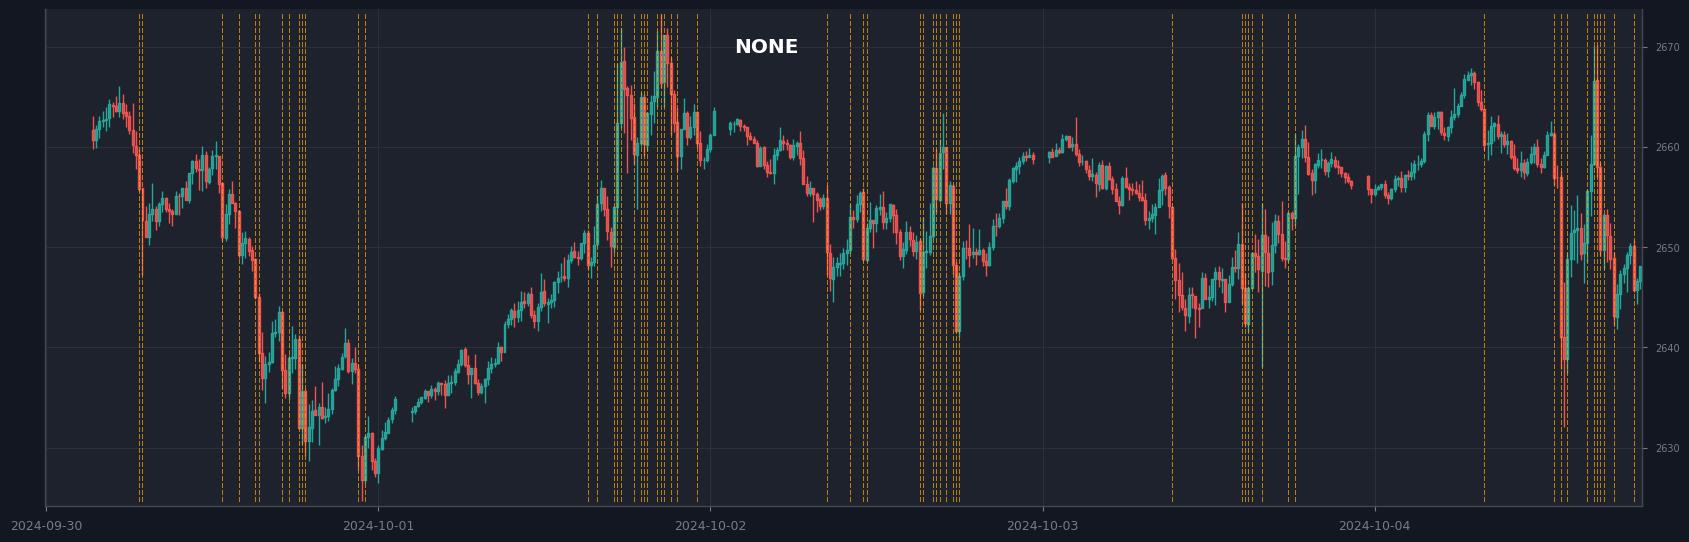

In [10]:
"""Creating The Main Chart"""

fig, axes =chartter.plot(
    dta,
    config=cnf,
    vlines = {
        'vlines': mask.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
    },
    returnfig=True
)

In [11]:
dta = resampler.resample(resultRaw,'15min', '2024-10-01', '2024-10-02')

mask = dta.index[dta['HL_above_400'] == True]

len(mask)


15

2025-10-19 15:46:13,802 [INFO] Generating chart d4288749-90ca-4ac2-a051-c668f0857c81 with 97 data points
2025-10-19 15:46:13,886 [INFO] Chart d4288749-90ca-4ac2-a051-c668f0857c81 generated successfully in 0.07s


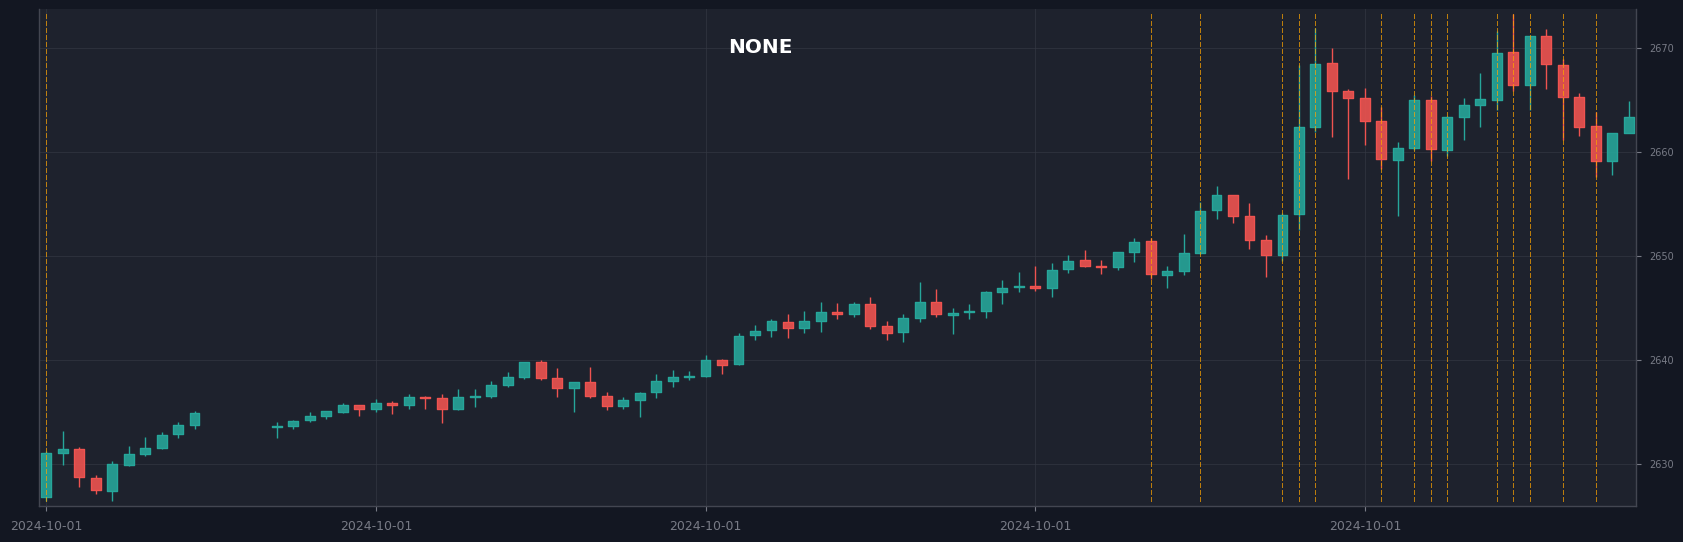

In [12]:
"""Creating The Main Chart"""

fig, axes =chartter.plot(
    dta,
    config=cnf,
    vlines = {
        'vlines': mask.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
    },
    returnfig=True
)

In [13]:
import pandas as pd

# Filter March data
df_march = result.copy()
df_march.index = pd.to_datetime(df_march.index)

# Number of candles before/after
window = 5

# List to store 11-candle windows
hl_windows = []

# Find all HL_above_400 True indices
true_indices = df_march.index[df_march['HL_above_400']].tolist()

for idx in true_indices:
    pos = df_march.index.get_loc(idx)
    start = max(0, pos - window)
    end = min(len(df_march), pos + window + 1)

    # Slice 11 candles
    sub_df = df_march.iloc[start:end].copy()

    # Optional: mark main candle
    sub_df['highlight'] = 0
    main_pos = pos - start
    sub_df.iloc[main_pos, sub_df.columns.get_loc('highlight')] = 1

    # Append to the list
    hl_windows.append(sub_df)

# Now hl_windows is a list of DataFrames
# Each DataFrame has 11 rows (or fewer if near start/end) and a 'highlight' column
print(f"Created {len(hl_windows)} HL windows")
# print(hl_windows[0])  # view first window


Created 2694 HL windows


In [ ]:
# print (x)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mplfinance.original_flavor import candlestick_ohlc
import math

# Number of columns per row
cols = 5
n_windows = len(hl_windows)
rows = math.ceil(n_windows / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=False)
axes = axes.flatten()  # flatten in case rows*cols > 1

for i, window_df in enumerate(hl_windows):
    ax = axes[i]

    # Prepare OHLC data
    ohlc = window_df[['open','high','low','close']].copy()
    ohlc['date'] = mdates.date2num(window_df.index.to_pydatetime())
    ohlc_vals = ohlc[['date','open','high','low','close']].values

    # Plot candlestick chart
    candlestick_ohlc(ax, ohlc_vals, width=0.03, colorup='g', colordown='r', alpha=0.8)

    # Highlight main candle
    main_idx = window_df['highlight'].idxmax()
    ax.axvline(mdates.date2num(main_idx), color='blue', linestyle='--', lw=2)

    ax.set_title(f"Window #{i+1} around {main_idx}")
    ax.xaxis_date()
    ax.grid(True)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### `GO deeper`